In [1]:
# Problem: Forecasting weather with Simple Linear Regression on time series data

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


In [6]:
import pandas as pd

# Link-gan wuxuu toos ugu xiran yahay Dataset-ka internetka
url = "https://raw.githubusercontent.com/datasets/global-temp/master/data/monthly.csv"

# Wuxuu toos uga akhrinayaa internetka isagoo aan Download la sameynin
df = pd.read_csv(url)

print(df.head())

  Source     Year    Mean
0   GCAG  1850-01 -0.7337
1   GCAG  1850-02 -0.3604
2   GCAG  1850-03 -0.6271
3   GCAG  1850-04 -0.6053
4   GCAG  1850-05 -0.5315


In [7]:
# Step 2: Filter the data for the country 'India
india_data = data[(data['Country'] == 'India') & (data['AvgTemperature'] > -99)].copy()

In [8]:
# Step 3: Combine the Month, Day and Year into a single Date column using .loc
india_data.loc[:, 'Date'] = pd.to_datetime(india_data[['Year', 'Month', 'Day']])


In [9]:
# Step 4: Select the relevant columns (Datetime, AvgTem)
rel_india_data = india_data[['Date', 'AvgTemperature']]


In [11]:
# Step 5: Preprocess the data.
# Models like Linear Regression cannot work with missing data, so we need to handle them.
# Weather data is measured daily and missing values might be a very few, So removing the missing values rows will be good here.
rel_india_data = rel_india_data.dropna()

# Date_ordinal column will contain integer values, which represent the date as a number, making it usable for the Linear Regression model.
# pd.Timestamp('1995-01-01').toordinal() might return 729216.
rel_india_data['Date_ordinal'] = rel_india_data['Date'].map(pd.Timestamp.toordinal)

X = rel_india_data[['Date_ordinal']] # Feature
y = rel_india_data['AvgTemperature'] # Target


In [12]:
# Step 6: Split the data
# Split into 80-20 ratio, training (80%) and validation (20%) datasets.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
# Step 7: Build and Train the model.
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# Step 8: Make predictions and Evaluate
predictions = model.predict(X_val)
mean_squared_error = mean_squared_error(y_val, predictions)
print(mean_squared_error)

74.02526667219969


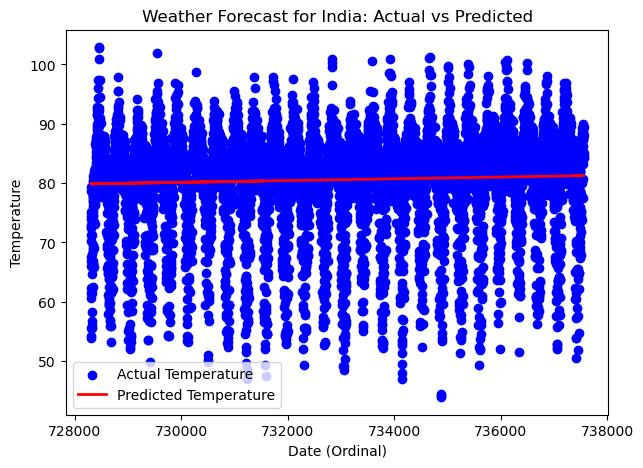

In [15]:
# Step 9: Visualization
plt.figure(figsize=(7, 5))
plt.scatter(X_val, y_val, color='blue', label='Actual Temperature')
plt.plot(X_val, predictions, color='red', linewidth=2, label='Predicted Temperature')
plt.xlabel('Date (Ordinal)')
plt.ylabel('Temperature')
plt.title('Weather Forecast for India: Actual vs Predicted')
plt.legend()
plt.show()